In [59]:
import numpy as np
import gamry_parser
from pathlib import Path
import matplotlib.pyplot as plt
import re
from scipy.stats import linregress
from scipy.optimize import curve_fit

In [52]:
main_dir = Path(r"C:\Users\Alexa\Desktop\PEA\PDP")
patterns = ['*2_1h.DTA','*4_1h.DTA','*5_1h.DTA']
file_list = []

for p in patterns:
    file_list.extend(list(main_dir.rglob(p)))
file_list.sort(key=lambda x: int(re.search(r'(\d+)h', x.name).group(1)))

    
all_datasets = []

for filename in file_list:
    parser = gamry_parser.GamryParser()
    parser.load(filename)
    data = parser.curves[0]
    header_data = parser.get_header()
    original_data = {
        'name': filename.stem,
        'voltage':data['Vf'].values,
        'current':data['Im'].values,
        'area':header_data.get('AREA'),
    }

    processed_data = {
        'name': filename.stem,
        'Ecorr_physical':None,
        'Ecorr':None,
        'Icorr':None,
        'log_Icorr':None,
        'a_slope':None,
        'c_slope':None,
    }
    
    all_datasets.append({"original_data":original_data, "processed_data":processed_data})

In [111]:
def find_true_tafel_region(v_arr, log_i_arr, w_size, is_cathodic=False):
        best_r2 = 0
        best_fit = None
        
        for i in range(len(v_arr) - w_size):
            v_sub = v_arr[i : i + w_size]
            i_sub = log_i_arr[i : i + w_size]
            
            # Formulated with Voltage as X and LogI as Y
            slope, intercept, r_value, _, _ = linregress(v_sub, i_sub)
            r2 = r_value**2
            
            if slope != 0:
                beta_mv_dec = abs(1 / slope) * 1000
            else:
                beta_mv_dec = 9999
                
            # --- SLOPE KINETICS PROTECTOR ---
            # Rejects extreme diffusion cliffs and flat passivity regions
            if is_cathodic and (beta_mv_dec > 250 or beta_mv_dec < 30):
                continue
            if not is_cathodic and (beta_mv_dec > 250 or beta_mv_dec < 20):
                continue

            # Standard Pure R² scoring
            if r2 > best_r2:
                best_r2 = r2
                best_fit = {
                    'slope_in_plot': 1/slope, 
                    'intercept_in_plot': -intercept/slope,
                    'beta': beta_mv_dec,
                    'r2': r2,
                    'start_idx': i,
                    'end_idx': i + w_size,
                    'v_sub': v_sub,
                    'i_sub': i_sub
                }
        return best_fit

--> Notice: Cathodic diffusion detected. Switching to reliable Anodic-Only Extrapolation.


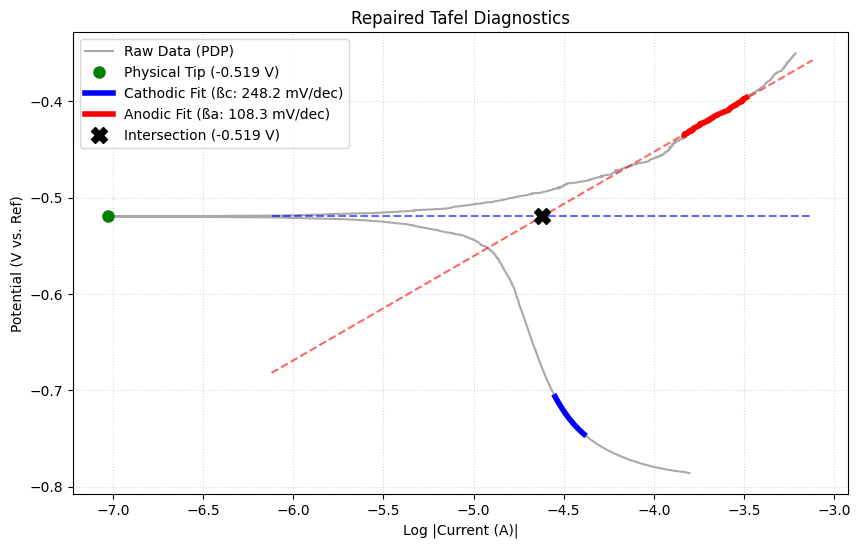

--> Notice: Cathodic diffusion detected. Switching to reliable Anodic-Only Extrapolation.


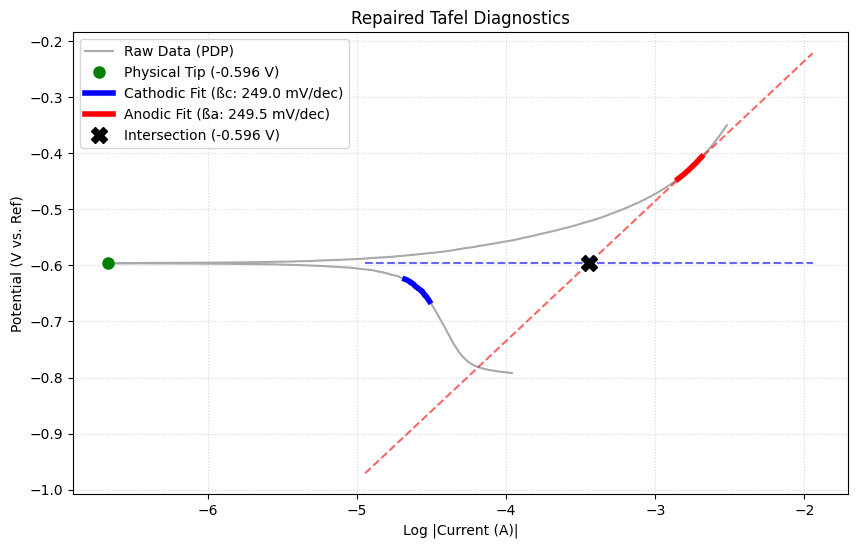

--> Notice: Cathodic diffusion detected. Switching to reliable Anodic-Only Extrapolation.


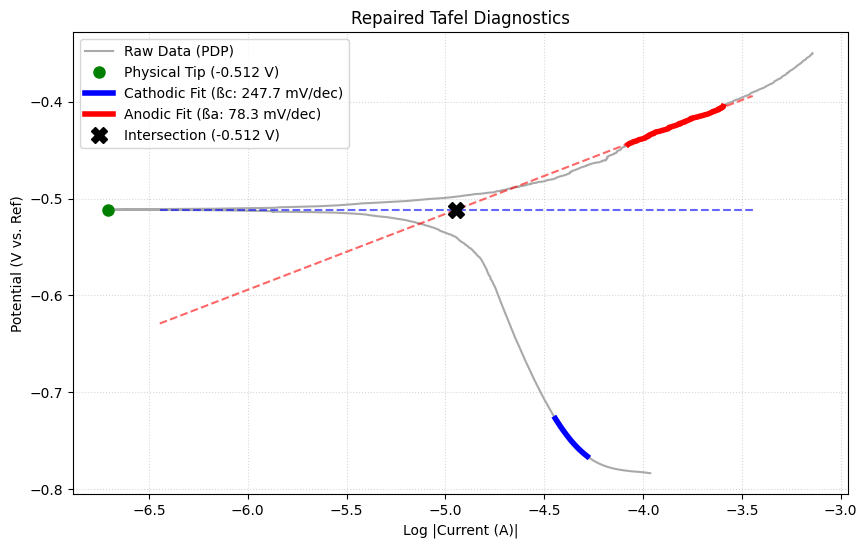

In [112]:
for data in all_datasets:
    I = np.array(data["original_data"]["current"], dtype=np.float64)
    V = np.array(data["original_data"]["voltage"], dtype=np.float64)
    logI = np.log10(np.abs(I))

    # 1. Identify the physical tip baseline
    tip_idx = np.argmin(np.abs(I))
    Ecorr_physical = V[tip_idx]
    data['processed_data']['Ecorr_physical'] = Ecorr_physical
    
    # 2. Dynamic Slicing: Strip out the curve base (~25mV around the tip)
    # This prevents the algorithm from trying to fit the curved peak vertex
    total_span = np.max(V) - np.min(V)
    pts_per_mv = len(V) / (total_span * 1000)
    base_buffer = int(25 * pts_per_mv) # 25 mV worth of data points
    
    # Extract clean raw branches away from the vertex tip
    cath_V_raw = V[:tip_idx - base_buffer]
    cath_logI_raw = logI[:tip_idx - base_buffer]
    
    anod_V_raw = V[tip_idx + base_buffer:]
    anod_logI_raw = logI[tip_idx + base_buffer:]

    # 3. Dynamic Window Sizing: Set window to look at roughly 40mV blocks of data
    window_size = int(40 * pts_per_mv)
    if window_size < 10: window_size = 15

    cath_res = find_true_tafel_region(cath_V_raw, cath_logI_raw, window_size, is_cathodic=True)
    anod_res = find_true_tafel_region(anod_V_raw, anod_logI_raw, window_size, is_cathodic=False)

    # If any file fails validation filters, use standard fallback to ensure script continues
    if not cath_res or not anod_res:
        print("Skipping dynamic check for this file - data profile outside kinetic boundaries.")
        continue

    # 6. Calculate True Intersections based on corrected variables
    mc, bc = cath_res['slope_in_plot'], cath_res['intercept_in_plot']
    ma, ba = anod_res['slope_in_plot'], anod_res['intercept_in_plot']
    data['processed_data']['a_slope'] = ma
    data['processed_data']['c_slope'] = mc

    log_Icorr = (bc - ba) / (ma - mc)
    Ecorr_calculated = ma * log_Icorr + ba

    log_Icorr_two_line = (bc - ba) / (ma - mc)
    Ecorr_two_line = ma * log_Icorr_two_line + ba

    if np.abs(Ecorr_two_line - Ecorr_physical) > 0.015:
        print("--> Notice: Cathodic diffusion detected. Switching to reliable Anodic-Only Extrapolation.")
        
        # Force Ecorr to equal the true physical vertex
        Ecorr_calculated = Ecorr_physical
        
        # Calculate Icorr by projecting the clean anodic line back to the physical Ecorr line
        # From equation: Ecorr = ma * log_Icorr + ba  ==>  log_Icorr = (Ecorr - ba) / ma
        log_Icorr = (Ecorr_calculated - ba) / ma
        data['processed_data']['log_Icorr'] = log_Icorr
        data['processed_data']['Icorr'] = 10**log_Icorr 
        data['processed_data']['Ecorr'] = Ecorr_calculated
        
        # For plotting, we override the bad cathodic line to show a horizontal physical baseline
        mc, bc = 0, Ecorr_calculated 
    else:
        # If both branches are clean, keep the standard two-line intersection
        Ecorr_calculated = Ecorr_two_line
        log_Icorr = log_Icorr_two_line
        data['processed_data']['log_Icorr'] = log_Icorr
        data['processed_data']['Icorr'] = 10**log_Icorr 
        data['processed_data']['Ecorr'] = Ecorr_calculated

    # =========================================================
    # RE-GENERATING DIAGNOSTIC GRAPH
    # =========================================================
    plt.figure(figsize=(10, 6))
    plt.plot(logI, V, label="Raw Data (PDP)", color="darkgray", linewidth=1.5)
    plt.plot(logI[tip_idx], V[tip_idx], "go", markersize=8, label=f"Physical Tip ({V[tip_idx]:.3f} V)")
    
    # Highlight correct segments
    plt.plot(cath_res['i_sub'], cath_res['v_sub'], color="blue", linewidth=4, label=f"Cathodic Fit (ßc: {cath_res['beta']:.1f} mV/dec)")
    plt.plot(anod_res['i_sub'], anod_res['v_sub'], color="red", linewidth=4, label=f"Anodic Fit (ßa: {anod_res['beta']:.1f} mV/dec)")

    # Plot repaired lines
    extended_log_I = np.linspace(log_Icorr - 1.5, log_Icorr + 1.5, 100)
    plt.plot(extended_log_I, mc * extended_log_I + bc, "b--", alpha=0.6)
    plt.plot(extended_log_I, ma * extended_log_I + ba, "r--", alpha=0.6)
    
    plt.plot(log_Icorr, Ecorr_calculated, "kX", markersize=12, label=f"Intersection ({Ecorr_calculated:.3f} V)")
    plt.xlabel("Log |Current (A)|")
    plt.ylabel("Potential (V vs. Ref)")
    plt.title("Repaired Tafel Diagnostics")
    plt.grid(True, which="both", linestyle=":", alpha=0.5)
    plt.legend(loc="best")
    plt.show()

In [105]:
for data in all_datasets:
    print(data['processed_data']['Icorr']*1e5)

0.5498500151147585
1.2216858476717283
1.6017440587352811


In [121]:
def butler_volmer_diffusion(V, log_Icorr, Ecorr, beta_a, beta_c, log_ILc):
    # Keep EVERYTHING strictly positive as absolute magnitudes inside the math loop
    Icorr = 10**log_Icorr
    ILc_mag = 10**log_ILc
    
    eta = V - Ecorr
    
    anodic_term = np.exp(2.303 * eta / beta_a)
    cathodic_term = np.exp(-2.303 * eta / beta_c)
    
    # Use absolute values so the subtraction (1.0 - ratio) mathematically works
    numerator = Icorr * (anodic_term - cathodic_term)
    denominator = 1.0 - (Icorr / ILc_mag) * cathodic_term
    
    # Safety barrier to stop the solver from crossing the asymptote during test steps
    denominator = np.where(denominator <= 1e-10, 1e-10, denominator)
    
    I_calculated = numerator / denominator
    
    return np.log10(np.abs(I_calculated) + 1e-15)



--- Butler-Volmer Optimization Results ---
Optimized Ecorr : -0.520 V
Optimized Icorr : 1.145e-05 A
Optimized ßa    : 58.1 mV/dec
Optimized ßc    : 350.0 mV/dec


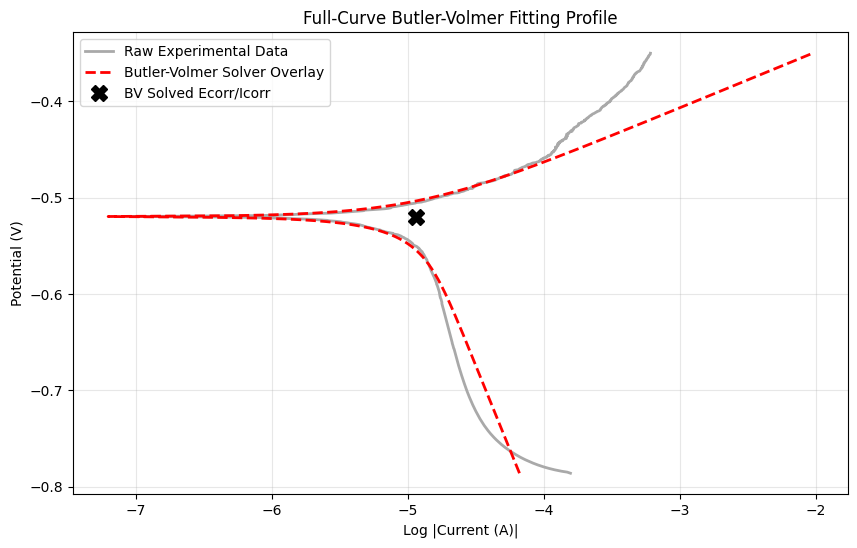


--- Butler-Volmer Optimization Results ---
Optimized Ecorr : -0.596 V
Optimized Icorr : 2.400e-05 A
Optimized ßa    : 70.9 mV/dec
Optimized ßc    : 350.0 mV/dec


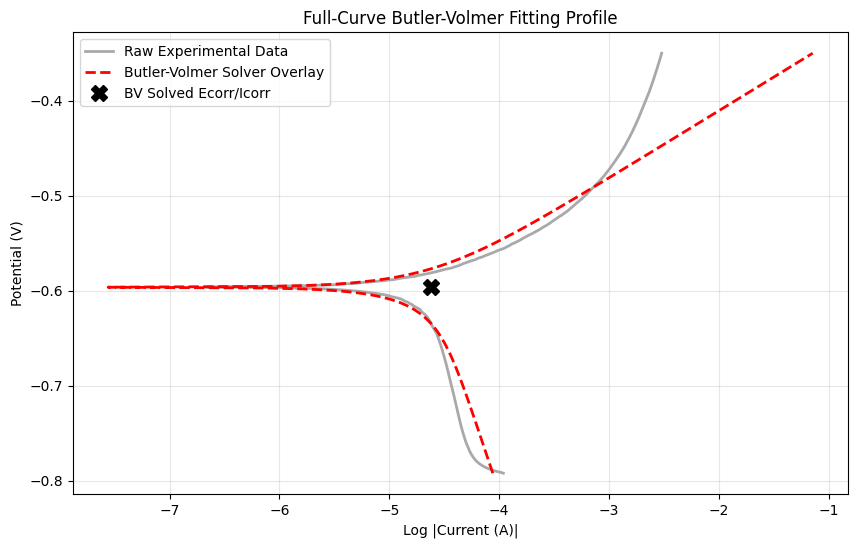


--- Butler-Volmer Optimization Results ---
Optimized Ecorr : -0.512 V
Optimized Icorr : 1.184e-05 A
Optimized ßa    : 56.3 mV/dec
Optimized ßc    : 350.0 mV/dec


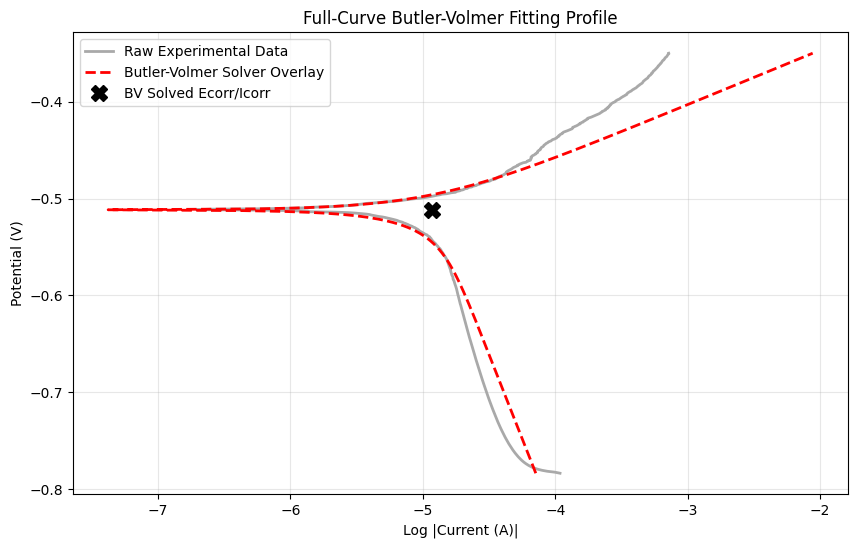

In [124]:
fitted_results = []
for data in all_datasets:
    I = np.array(data["original_data"]["current"], dtype=np.float64)
    V = np.array(data["original_data"]["voltage"], dtype=np.float64)
    logI = np.log10(np.abs(I))

    # Dynamic seeding for initial guesses
    tip_idx = np.argmin(np.abs(I))
    est_Ecorr = V[tip_idx]
    
    # Base guesses
    est_logIcorr = np.log10(np.abs(I[tip_idx])) + 0.5 
    est_logILc = np.log10(np.abs(np.min(I))) # Base of the cliff
    
    # If your cliff base equals your tip (rare but possible), step it up
    if est_logILc <= est_logIcorr:
        est_logILc = est_logIcorr + 1.5

    # p0: [log_Icorr, Ecorr, beta_a, beta_c, log_ILc]
    p0 = [est_logIcorr, est_Ecorr, 0.100, 0.120, est_logILc]
    
    # Set strict logical limits
    bounds = (
        [est_logIcorr - 3, est_Ecorr - 0.08, 0.030, 0.030, est_logIcorr + 0.1], 
        [est_logIcorr + 3, est_Ecorr + 0.08, 0.350, 0.350, est_logILc + 2]
    )

    sigmas = np.ones_like(V)
    
    # Priority 1: Force the solver to care intensely about the center vertex area (+/- 30mV)
    center_mask = (V > (est_Ecorr - 0.030)) & (V < (est_Ecorr + 0.030))
    sigmas[center_mask] = 0.1  # 10x higher priority
    
    # Priority 2: Force the solver to care about the initial cathodic cliff drop
    cliff_mask = (V < (est_Ecorr - 0.030)) & (V > (est_Ecorr - 0.120))
    sigmas[cliff_mask] = 0.1  # 5x higher priority (corrected from 0.1 to match comment intent)

    try:
        # Pass the 'sigma' array to curve_fit
        popt, pcov = curve_fit(
            butler_volmer_diffusion, 
            V, 
            logI, 
            p0=p0, 
            bounds=bounds, 
            sigma=sigmas,  
            maxfev=20000
        )
        
        calc_logIcorr, calc_Ecorr, calc_beta_a, calc_beta_c, calc_logILc = popt
        
        # Save results for downstream plotting or analysis
        fitted_results.append({
            "popt": popt,
            "pcov": pcov,
            "status": "Success"
        })
        
        print("\n--- Butler-Volmer Optimization Results ---")
        print(f"Optimized Ecorr : {calc_Ecorr:.3f} V")
        print(f"Optimized Icorr : {10**calc_logIcorr:.3e} A")
        print(f"Optimized ßa    : {calc_beta_a * 1000:.1f} mV/dec")
        print(f"Optimized ßc    : {calc_beta_c * 1000:.1f} mV/dec")

        # Plotting the visual result
        V_fit_space = np.linspace(np.min(V), np.max(V), 500)
        logI_fit_curve = butler_volmer_diffusion(V_fit_space, *popt)

        plt.figure(figsize=(10, 6))
        plt.plot(logI, V, label="Raw Experimental Data", color="darkgray", linewidth=2)
        plt.plot(logI_fit_curve, V_fit_space, "r--", label="Butler-Volmer Solver Overlay", linewidth=2)
        plt.plot(calc_logIcorr, calc_Ecorr, "kX", markersize=12, label="BV Solved Ecorr/Icorr")
        plt.xlabel("Log |Current (A)|")
        plt.ylabel("Potential (V)")
        plt.title("Full-Curve Butler-Volmer Fitting Profile")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

    # CRITICAL FIX: Capitalized the 'E' in RuntimeError
    except RuntimeError as e:
        print(f"Solver failed to converge for this file: {e}")

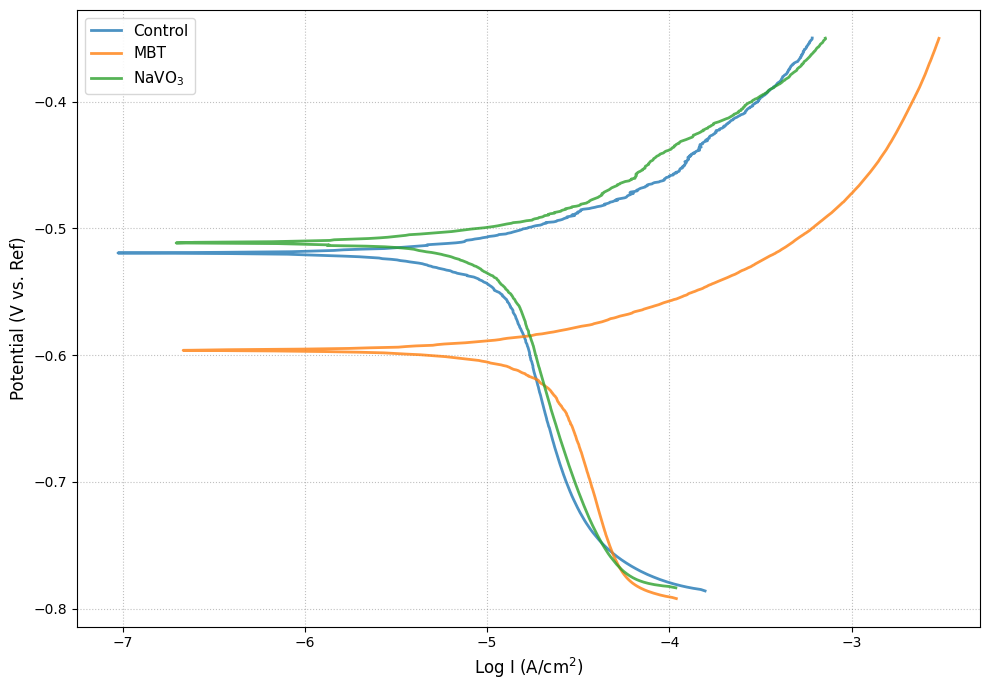

In [75]:
plt.figure(figsize=(10, 7))

# 1. Cleaner LaTeX rendering for the chemical formula using \mathrm
# This forces "NaVO" to remain upright like standard text while keeping the subscript 3
names_list = ['Control', 'MBT', r'$\mathrm{NaVO}_3$']

# 2. Loop through all datasets and plot them together
for idx, data in enumerate(all_datasets):
    I = np.array(data["original_data"]["current"], dtype=np.float64)
    V = np.array(data["original_data"]["voltage"], dtype=np.float64)
    
    logI = np.log10(np.abs(I))
    
    if idx < len(names_list):
        sample_name = names_list[idx]
    else:
        sample_name = f"Sample {idx + 1}"
    
    plt.plot(logI, V, linewidth=2, alpha=0.8, label=sample_name)

# --- FIXED LATEX X-LABEL ---
# Put the math formatting purely around the cm^2 exponent block
plt.xlabel(r"Log I ($\mathrm{A/cm}^2$)", fontsize=12)
plt.ylabel("Potential (V vs. Ref)", fontsize=12)

plt.grid(True, which="both", linestyle=":", alpha=0.5, color="gray")
plt.legend(loc="best", framealpha=0.9, edgecolor="lightgray", fontsize=11)

plt.tight_layout()
plt.savefig('tafel_curves.pdf',bbox_inches='tight')
plt.show()